This project implements a conditional 3D diffusion model for MRI modality translation (T1 to T2) using MONAI. The model is based on a Denoising Diffusion Probabilistic Model (DDPM), where Gaussian noise is progressively added to the target T2 images and a neural network is trained to predict and remove this noise.

A DiffusionModelUNet is used as the denoising backbone, operating directly in voxel space. The model is conditioned on T1 MRI volumes by concatenating them with the noisy T2 input. During training, the model learns to predict the noise added at each timestep using a mean squared error loss.

During inference, the model generates synthetic T2 images by iteratively denoising random noise conditioned on T1 input.

This approach is inspired by Stable Diffusion, but differs in that it operates in full image space instead of latent space, and uses MRI volumes as conditioning input instead of text embeddings.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!gdown --fuzzy "https://drive.google.com/file/d/1p1SLWwJLfkt03PHw2sFFPcLe1-jePknu/view?usp=sharing"

Mounted at /content/drive
Downloading...
From (original): https://drive.google.com/uc?id=1p1SLWwJLfkt03PHw2sFFPcLe1-jePknu
From (redirected): https://drive.google.com/uc?id=1p1SLWwJLfkt03PHw2sFFPcLe1-jePknu&confirm=t&uuid=ecff7631-036e-48b5-8225-38579c84846e
To: /content/BraTS2020_T1_FLAIR_Flat.zip
100% 2.20G/2.20G [00:36<00:00, 60.3MB/s]


In [ ]:
!unzip "/content/BraTS2020_T1_FLAIR_Flat.zip" -d "/content/dataset"

Archive:  /content/BraTS2020_T1_FLAIR_Flat.zip
   creating: /content/dataset/BraTS2020_T1_FLAIR_Flat/
  inflating: /content/dataset/BraTS2020_T1_FLAIR_Flat/BraTS20_Training_001_flair.nii  
  inflating: /content/dataset/BraTS2020_T1_FLAIR_Flat/BraTS20_Training_001_t1.nii  
  inflating: /content/dataset/BraTS2020_T1_FLAIR_Flat/BraTS20_Training_002_flair.nii  
  inflating: /content/dataset/BraTS2020_T1_FLAIR_Flat/BraTS20_Training_002_t1.nii  
  inflating: /content/dataset/BraTS2020_T1_FLAIR_Flat/BraTS20_Training_003_flair.nii  
  inflating: /content/dataset/BraTS2020_T1_FLAIR_Flat/BraTS20_Training_003_t1.nii  
  inflating: /content/dataset/BraTS2020_T1_FLAIR_Flat/BraTS20_Training_004_flair.nii  
  inflating: /content/dataset/BraTS2020_T1_FLAIR_Flat/BraTS20_Training_004_t1.nii  
  inflating: /content/dataset/BraTS2020_T1_FLAIR_Flat/BraTS20_Training_005_flair.nii  
  inflating: /content/dataset/BraTS2020_T1_FLAIR_Flat/BraTS20_Training_005_t1.nii  
  inflating: /content/dataset/BraTS2020_T1_

In [ ]:
!pip install -q monai nibabel matplotlib tqdm
!pip install -q "monai-generative"
!pip install monai-generative
!pip install lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 99.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.9 MB/s eta 0:00:00


# **Data Preparation**



In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc
import random
from pathlib import Path

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ResizeWithPadOrCropd,
    EnsureTyped,
    RandFlipd,
    RandRotate90d,
    RandAffined
)
from monai.data import Dataset
from monai.utils import set_determinism

from generative.networks.nets import DiffusionModelUNet
from generative.networks.schedulers import DDPMScheduler
import os
import shutil
import tempfile

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from monai import transforms
from monai.apps import DecathlonDataset
from monai.config import print_config
from monai.data import DataLoader
from monai.utils import first, set_determinism
from torch.cuda.amp import GradScaler, autocast
from torch.nn import L1Loss
from tqdm import tqdm

from generative.inferers import LatentDiffusionInferer
from generative.losses import PatchAdversarialLoss, PerceptualLoss
from generative.networks.nets import AutoencoderKL, DiffusionModelUNet, PatchDiscriminator
from generative.networks.schedulers import DDPMScheduler

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
/usr/local/lib/python3.12/dist-packages/generative/networks/layers/vector_quantizer.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)
/usr/local/lib/python3.12/dist-packages/generative/networks/layers/vector_quantizer.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


In [ ]:
set_determinism(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Update these paths
flat_dir = Path("/content/dataset/BraTS2020_T1_FLAIR_Flat")

print("Flat folder exists:", flat_dir.exists())
print("Example files:", list(flat_dir.glob("*"))[:5])

output_dir = Path("/content/drive/MyDrive/fyp_ldm_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

# Start smaller first if using Colab T4
spatial_size = (96, 96, 96)
batch_size = 4
num_workers = 8

ae_epochs = 50
diff_epochs = 100

ae_lr = 5e-5
diff_lr = 5e-5

num_train_timesteps = 1000

Using device: cuda
Flat folder exists: True
Example files: [PosixPath('/content/dataset/BraTS2020_T1_FLAIR_Flat/BraTS20_Validation_019_flair.nii'), PosixPath('/content/dataset/BraTS2020_T1_FLAIR_Flat/BraTS20_Validation_082_flair.nii'), PosixPath('/content/dataset/BraTS2020_T1_FLAIR_Flat/BraTS20_Training_243_t1.nii'), PosixPath('/content/dataset/BraTS2020_T1_FLAIR_Flat/BraTS20_Training_263_t1.nii'), PosixPath('/content/dataset/BraTS2020_T1_FLAIR_Flat/BraTS20_Training_302_t1.nii')]


In [ ]:
def build_paired_data_flat(flat_dir: Path):
    flat_dir = Path(flat_dir)

    t1_files = sorted([
        f for f in flat_dir.glob("*.nii*")
        if f.name.lower().endswith("_t1.nii") or f.name.lower().endswith("_t1.nii.gz")
    ])

    pairs = []

    print("Found T1 files:", len(t1_files))
    print("Example T1 files:", [f.name for f in t1_files[:5]])

    for t1_path in t1_files:
        if t1_path.name.endswith("_t1.nii.gz"):
            flair_name = t1_path.name.replace("_t1.nii.gz", "_flair.nii.gz")
            case_id = t1_path.name.replace("_t1.nii.gz", "")

        elif t1_path.name.endswith("_t1.nii"):
            flair_name = t1_path.name.replace("_t1.nii", "_flair.nii")
            case_id = t1_path.name.replace("_t1.nii", "")

        else:
            continue

        flair_path = flat_dir / flair_name

        if flair_path.exists():
            pairs.append({
                "t1": str(t1_path),
                "flair": str(flair_path),
                "id": case_id
            })
        else:
            print("Missing FLAIR for:", t1_path.name)
            print("Expected:", flair_name)

    if len(pairs) == 0:
        raise ValueError("No paired T1/FLAIR files found. Check folder path and filenames.")

    return pairs

data_dicts = build_paired_data_flat(flat_dir)

print("Total paired cases:", len(data_dicts))
print(data_dicts[:3])

Found T1 files: 494
Example T1 files: ['BraTS20_Training_001_t1.nii', 'BraTS20_Training_002_t1.nii', 'BraTS20_Training_003_t1.nii', 'BraTS20_Training_004_t1.nii', 'BraTS20_Training_005_t1.nii']
Total paired cases: 494
[{'t1': '/content/dataset/BraTS2020_T1_FLAIR_Flat/BraTS20_Training_001_t1.nii', 'flair': '/content/dataset/BraTS2020_T1_FLAIR_Flat/BraTS20_Training_001_flair.nii', 'id': 'BraTS20_Training_001'}, {'t1': '/content/dataset/BraTS2020_T1_FLAIR_Flat/BraTS20_Training_002_t1.nii', 'flair': '/content/dataset/BraTS2020_T1_FLAIR_Flat/BraTS20_Training_002_flair.nii', 'id': 'BraTS20_Training_002'}, {'t1': '/content/dataset/BraTS2020_T1_FLAIR_Flat/BraTS20_Training_003_t1.nii', 'flair': '/content/dataset/BraTS2020_T1_FLAIR_Flat/BraTS20_Training_003_flair.nii', 'id': 'BraTS20_Training_003'}]


In [ ]:
#split the dataset 80-10-10
random.shuffle(data_dicts)

n = len(data_dicts)
train_end = int(0.8 * n)
val_end = int(0.9 * n)

train_files = data_dicts[:train_end]
val_files = data_dicts[train_end:val_end]
test_files = data_dicts[val_end:]

print("Train:", len(train_files))
print("Val:", len(val_files))
print("Test:", len(test_files))

Train: 395
Val: 49
Test: 50


In [ ]:
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    Spacingd,
    CropForegroundd,
    SpatialPadd,
    CenterSpatialCropd,
    ScaleIntensityRangePercentilesd,
    EnsureTyped,
    RandFlipd,
    RandRotate90d,
    RandAffined,
)

transforms_3d = Compose([
    LoadImaged(keys=["t1", "flair"]),
    EnsureChannelFirstd(keys=["t1", "flair"]),
    EnsureTyped(keys=["t1", "flair"]),

    Orientationd(keys=["t1", "flair"], axcodes="RAS"),

    Spacingd(
        keys=["t1", "flair"],
        pixdim=(1.5, 1.5, 1.5),
        mode=("bilinear", "bilinear")
    ),

    CropForegroundd(
        keys=["t1", "flair"],
        source_key="t1"
    ),

    SpatialPadd(
        keys=["t1", "flair"],
        spatial_size=(96, 96, 64)
    ),

    CenterSpatialCropd(
        keys=["t1", "flair"],
        roi_size=(96, 96, 64)
    ),

    ScaleIntensityRangePercentilesd(
        keys=["t1", "flair"],
        lower=0,
        upper=99.5,
        b_min=-1.0,
        b_max=1.0,
        clip=True,
    ),

    RandFlipd(
        keys=["t1", "flair"],
        prob=0.5,
        spatial_axis=0
    ),

    RandFlipd(
        keys=["t1", "flair"],
        prob=0.5,
        spatial_axis=1
    ),

    RandRotate90d(
        keys=["t1", "flair"],
        prob=0.5,
        max_k=3
    ),

    RandAffined(
        keys=["t1", "flair"],
        prob=0.3,
        rotate_range=(0.1, 0.1, 0.1),
        scale_range=(0.1, 0.1, 0.1),
        mode=("bilinear", "bilinear"),
    ),
])

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [ ]:
from monai.transforms import LoadImaged, EnsureChannelFirstd, Compose
from monai.data import Dataset
from torch.utils.data import DataLoader

train_ds = Dataset(data=train_files, transform=transforms_3d)
val_ds = Dataset(data=val_files, transform=transforms_3d)
test_ds = Dataset(data=test_files, transform=transforms_3d)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=num_workers)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 99
Val batches: 49
Test batches: 50


In [ ]:
#visualize one sample
import matplotlib.pyplot as plt

target_batch_idx = 1  # Batch 012

for batch_idx, batch in enumerate(test_loader):
    if batch_idx == target_batch_idx:
        t1 = batch["t1"][0, 0].cpu().numpy()
        flair = batch["flair"][0, 0].cpu().numpy()

        z = t1.shape[2] // 2

        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        plt.imshow(t1[:, :, z], cmap="gray")
        plt.title(f"T1 - Batch {batch_idx:03d}")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(flair[:, :, z], cmap="gray")
        plt.title(f"Flair - Batch {batch_idx:03d}")
        plt.axis("off")

        plt.show()

        print("Batch index:", batch_idx)
        print("T1 shape:", batch["t1"].shape)
        print("Flair shape:", batch["flair"].shape)

        break

NameError: name 'test_loader' is not defined

Comparing Case: BraTS20_Training_152


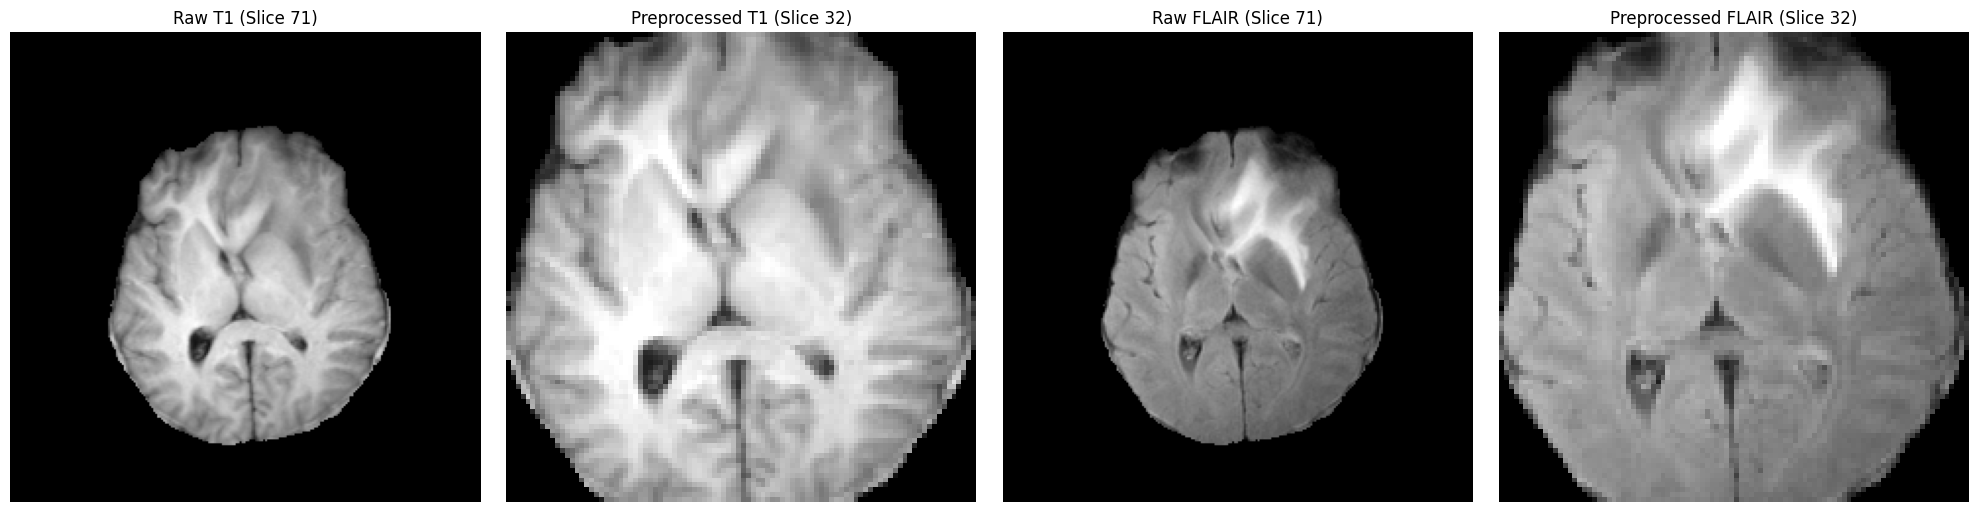

In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# Let's pick a random case from our test_files to compare
case_idx = 0
raw_t1_path = test_files[case_idx]['t1']
raw_flair_path = test_files[case_idx]['flair']

print(f"Comparing Case: {test_files[case_idx]['id']}")

# Load raw data and convert to canonical (RAS+) orientation to match MONAI's preprocessed orientation
raw_t1_img = nib.as_closest_canonical(nib.load(raw_t1_path)).get_fdata()
raw_flair_img = nib.as_closest_canonical(nib.load(raw_flair_path)).get_fdata()

# The dataloader applies random augmentations if shuffle=True,
# but since test_loader has shuffle=False, we can just grab the corresponding batch.
target_batch_idx = case_idx

# Get preprocessed data from dataloader
preprocessed_batch = None
for i, batch in enumerate(test_loader):
    if i == target_batch_idx:
        preprocessed_batch = batch
        break

if preprocessed_batch is not None:
    prep_t1 = preprocessed_batch["t1"][0, 0].cpu().numpy()
    prep_flair = preprocessed_batch["flair"][0, 0].cpu().numpy()

    prep_z = prep_t1.shape[2] // 2

    # Calculate the equivalent raw slice by finding the center of the brain
    # (foreground) in the raw image along the Z axis.
    z_indices = np.any(raw_t1_img > 0, axis=(0, 1))
    if np.any(z_indices):
        z_min, z_max = np.where(z_indices)[0][[0, -1]]
        raw_z = int((z_min + z_max) // 2)
    else:
        raw_z = raw_t1_img.shape[2] // 2

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # Raw T1
    axes[0].imshow(np.rot90(raw_t1_img[:, :, raw_z]), cmap="gray")
    axes[0].set_title(f"Raw T1 (Slice {raw_z})")
    axes[0].axis("off")

    # Preprocessed T1
    axes[1].imshow(prep_t1[:, :, prep_z], cmap="gray")
    axes[1].set_title(f"Preprocessed T1 (Slice {prep_z})")
    axes[1].axis("off")

    # Raw FLAIR
    axes[2].imshow(np.rot90(raw_flair_img[:, :, raw_z]), cmap="gray")
    axes[2].set_title(f"Raw FLAIR (Slice {raw_z})")
    axes[2].axis("off")

    # Preprocessed FLAIR
    axes[3].imshow(prep_flair[:, :, prep_z], cmap="gray")
    axes[3].set_title(f"Preprocessed FLAIR (Slice {prep_z})")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Could not find the corresponding batch in test_loader.")

Autoencoder

In [ ]:
from generative.inferers import LatentDiffusionInferer
from generative.networks.nets import AutoencoderKL, DiffusionModelUNet, PatchDiscriminator
from generative.networks.schedulers import DDPMScheduler

In [ ]:
autoencoder = AutoencoderKL(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    num_channels=(64, 128, 256),
    latent_channels=8,
    num_res_blocks=2,
    norm_num_groups=16,
    attention_levels=(False, False, True),
).to(device)

kl_weight = 0
perceptual_weight = 0
adv_weight = 0
autoencoder_warm_up_n_epochs = 30

Define loss

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

autoencoder.to(device)


optimizer_g = torch.optim.AdamW(autoencoder.parameters(), lr=5e-5, weight_decay=1e-6)

scheduler_g = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_g,
    mode="min",          # because lower val_recon_loss is better
    factor=0.5,          # reduce LR by half
    patience=5,          # wait 4 bad epochs
    threshold=1e-4,
    min_lr=1e-6
)


l1_loss = L1Loss()
adv_loss = PatchAdversarialLoss(criterion="least_squares")

loss_perceptual = PerceptualLoss(
    spatial_dims=3,
    network_type="squeeze",
    is_fake_3d=True,
    fake_3d_ratio=0.2,
).to(device)

def KL_loss(z_mu, z_sigma):
    eps = 1e-8
    kl = 0.5 * torch.sum(
        z_mu.pow(2) + z_sigma.pow(2) - torch.log(z_sigma.pow(2) + eps) - 1,
        dim=[1, 2, 3, 4],
    )
    return kl.mean()


scaler_g = GradScaler(enabled=(device.type == "cuda"))
scaler_d = GradScaler(enabled=(device.type == "cuda"))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


100%|██████████| 4.73M/4.73M [00:00<00:00, 52.1MB/s]
/tmp/ipykernel_528/740208858.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_g = GradScaler(enabled=(device.type == "cuda"))
/tmp/ipykernel_528/740208858.py:38: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_d = GradScaler(enabled=(device.type == "cuda"))


In [ ]:
import os
import numpy as np
import torch
from tqdm import tqdm
from google.colab import drive
from torch.amp import autocast, GradScaler
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# =========================================================
# 0. MOUNT GOOGLE DRIVE
# =========================================================
drive.mount("/content/drive")

save_dir = "/content/drive/MyDrive/fyp_checkpoints"
os.makedirs(save_dir, exist_ok=True)

# Using new names for the shared autoencoder
latest_ckpt_path = os.path.join(save_dir, "autoencoder_latest_flair.pth")
best_ckpt_path = os.path.join(save_dir, "autoencoder_best_flair.pth")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

autoencoder = autoencoder.to(device)


# =========================================================
# 1. TRAINING CONFIG
# =========================================================
n_epochs = 100
autoencoder_warm_up_n_epochs = 5
resume_training = True

best_val_ssim = -1.0
best_val_recon_loss = float("inf")

early_stop_patience = 15
no_improve_epochs = 0


# =========================================================
# 2. AMP SCALERS
# =========================================================
scaler_g = GradScaler("cuda", enabled=(device.type == "cuda"))
scaler_d = GradScaler("cuda", enabled=(device.type == "cuda"))


# =========================================================
# 3. HISTORY
# =========================================================
start_epoch = 0

epoch_recon_loss_list = []
epoch_gen_loss_list = []
epoch_disc_loss_list = []

val_recon_epoch_loss_list = []
val_psnr_epoch_list = []
val_ssim_epoch_list = []


# =========================================================
# 4. OPTIONAL: RESUME FROM LATEST CHECKPOINT
# =========================================================
if resume_training and os.path.exists(latest_ckpt_path):
    checkpoint = torch.load(latest_ckpt_path, map_location=device)

    autoencoder.load_state_dict(checkpoint["autoencoder_state_dict"])
    optimizer_g.load_state_dict(checkpoint["optimizer_g_state_dict"])

    scaler_g.load_state_dict(checkpoint["scaler_g_state_dict"])
    scaler_d.load_state_dict(checkpoint["scaler_d_state_dict"])

    start_epoch = checkpoint["epoch"]

    epoch_recon_loss_list = checkpoint.get("epoch_recon_loss_list", [])
    epoch_gen_loss_list = checkpoint.get("epoch_gen_loss_list", [])
    epoch_disc_loss_list = checkpoint.get("epoch_disc_loss_list", [])

    val_recon_epoch_loss_list = checkpoint.get("val_recon_epoch_loss_list", [])
    val_psnr_epoch_list = checkpoint.get("val_psnr_epoch_list", [])
    val_ssim_epoch_list = checkpoint.get("val_ssim_epoch_list", [])

    best_val_recon_loss = checkpoint.get("best_val_recon_loss", float("inf"))
    best_val_ssim = checkpoint.get("best_val_ssim", -1.0)
    no_improve_epochs = checkpoint.get("no_improve_epochs", 0)

    print(f"Resumed from epoch {start_epoch}")


# =========================================================
# 5. VALIDATION FUNCTION FOR SHARED AUTOENCODER
# =========================================================
@torch.no_grad()
def validate_autoencoder(autoencoder, val_loader, device):
    autoencoder.eval()

    val_recon_loss = 0.0
    val_psnr_list = []
    val_ssim_list = []
    num_batches = 0

    progress_bar = tqdm(
        val_loader,
        total=len(val_loader),
        ncols=110,
        desc="Validation",
        leave=False
    )

    for batch in progress_bar:
        t1 = batch["t1"].to(device)
        flair = batch["flair"].to(device)

        # Concatenate along the batch dimension to process both
        images = torch.cat([t1, flair], dim=0)

        with autocast("cuda", enabled=(device.type == "cuda")):
            reconstruction, z_mu, z_sigma = autoencoder(images)
            recon_loss = l1_loss(reconstruction.float(), images.float())

        val_recon_loss += recon_loss.item()
        num_batches += 1

        recon_np = reconstruction.detach().cpu().numpy()
        gt_np = images.detach().cpu().numpy()

        for i in range(recon_np.shape[0]):
            pred_vol = recon_np[i, 0]
            gt_vol = gt_np[i, 0]

            # Clip to training range [-1, 1]
            pred_vol = np.clip(pred_vol, -1.0, 1.0)
            gt_vol = np.clip(gt_vol, -1.0, 1.0)

            # Rescale to [0, 1] for PSNR / SSIM
            pred_vol = (pred_vol + 1.0) / 2.0
            gt_vol = (gt_vol + 1.0) / 2.0

            psnr_val = psnr(
                gt_vol,
                pred_vol,
                data_range=1.0
            )
            val_psnr_list.append(psnr_val)

            ssim_slices = []

            for z in range(pred_vol.shape[2]):
                ssim_val = ssim(
                    gt_vol[:, :, z],
                    pred_vol[:, :, z],
                    data_range=1.0
                )
                ssim_slices.append(ssim_val)

            val_ssim_list.append(np.mean(ssim_slices))

        progress_bar.set_postfix({
            "val_recon_loss": val_recon_loss / max(num_batches, 1),
            "val_psnr": float(np.mean(val_psnr_list)) if len(val_psnr_list) > 0 else 0.0,
            "val_ssim": float(np.mean(val_ssim_list)) if len(val_ssim_list) > 0 else 0.0,
        })

    mean_val_recon = val_recon_loss / max(num_batches, 1)
    mean_val_psnr = float(np.mean(val_psnr_list)) if len(val_psnr_list) > 0 else 0.0
    mean_val_ssim = float(np.mean(val_ssim_list)) if len(val_ssim_list) > 0 else 0.0

    return mean_val_recon, mean_val_psnr, mean_val_ssim


# =========================================================
# 6. TRAINING LOOP
# =========================================================
for epoch in range(start_epoch, n_epochs):
    autoencoder.train()

    epoch_recon_loss = 0.0
    epoch_gen_loss = 0.0
    epoch_disc_loss = 0.0

    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        ncols=110
    )

    progress_bar.set_description(f"Epoch {epoch + 1}/{n_epochs}")

    for step, batch in progress_bar:
        t1 = batch["t1"].to(device)
        flair = batch["flair"].to(device)

        # Concatenate along the batch dimension to process both modalities
        images = torch.cat([t1, flair], dim=0)

        optimizer_g.zero_grad(set_to_none=True)

        with autocast("cuda", enabled=(device.type == "cuda")):
            reconstruction, z_mu, z_sigma = autoencoder(images)

            kl_loss = KL_loss(z_mu, z_sigma)
            recon_loss = l1_loss(reconstruction.float(), images.float())

            loss = recon_loss + kl_weight * kl_loss

        scaler_g.scale(loss).backward()
        scaler_g.step(optimizer_g)
        scaler_g.update()

        epoch_recon_loss += recon_loss.item()

        progress_bar.set_postfix({
            "recon_loss": epoch_recon_loss / (step + 1),
        })

    # -----------------------------------------------------
    # Epoch averages
    # -----------------------------------------------------
    avg_recon_loss = epoch_recon_loss / len(train_loader)
    avg_gen_loss = epoch_gen_loss / len(train_loader)
    avg_disc_loss = epoch_disc_loss / len(train_loader)

    epoch_recon_loss_list.append(avg_recon_loss)
    epoch_gen_loss_list.append(avg_gen_loss)
    epoch_disc_loss_list.append(avg_disc_loss)

    # -----------------------------------------------------
    # Validation
    # -----------------------------------------------------
    val_recon_loss, val_psnr, val_ssim = validate_autoencoder(
        autoencoder,
        val_loader,
        device
    )

    scheduler_g.step(val_recon_loss)
    current_lr = optimizer_g.param_groups[0]["lr"]

    val_recon_epoch_loss_list.append(val_recon_loss)
    val_psnr_epoch_list.append(val_psnr)
    val_ssim_epoch_list.append(val_ssim)

    print(
        f"Epoch {epoch + 1}/{n_epochs} | "
        f"train_recon={avg_recon_loss:.6f} | "
        f"val_recon={val_recon_loss:.6f} | "
        f"val_psnr={val_psnr:.4f} | "
        f"val_ssim={val_ssim:.4f} | "
        f"lr={current_lr:.2e}"
    )

    # -----------------------------------------------------
    # Save latest checkpoint
    # -----------------------------------------------------
    checkpoint = {
        "epoch": epoch + 1,
        "autoencoder_state_dict": autoencoder.state_dict(),
        "optimizer_g_state_dict": optimizer_g.state_dict(),
        "scheduler_g_state_dict": scheduler_g.state_dict(),
        "scaler_g_state_dict": scaler_g.state_dict(),
        "scaler_d_state_dict": scaler_d.state_dict(),

        "epoch_recon_loss_list": epoch_recon_loss_list,
        "epoch_gen_loss_list": epoch_gen_loss_list,
        "epoch_disc_loss_list": epoch_disc_loss_list,

        "val_recon_epoch_loss_list": val_recon_epoch_loss_list,
        "val_psnr_epoch_list": val_psnr_epoch_list,
        "val_ssim_epoch_list": val_ssim_epoch_list,

        "best_val_recon_loss": best_val_recon_loss,
        "best_val_ssim": best_val_ssim,
        "no_improve_epochs": no_improve_epochs,

        "val_recon_loss": val_recon_loss,
        "val_psnr": val_psnr,
        "val_ssim": val_ssim,
    }

    torch.save(checkpoint, latest_ckpt_path)
    print(f"Saved latest checkpoint -> {latest_ckpt_path}")

    # -----------------------------------------------------
    # Save best checkpoint by SSIM & Early Stopping Check
    # -----------------------------------------------------
    if val_ssim > best_val_ssim:
        best_val_ssim = val_ssim
        no_improve_epochs = 0

        checkpoint["best_val_ssim"] = best_val_ssim
        checkpoint["no_improve_epochs"] = no_improve_epochs
        torch.save(checkpoint, best_ckpt_path)

        print(
            f"Saved BEST checkpoint -> {best_ckpt_path} "
            f"(val_ssim={best_val_ssim:.4f})"
        )
    else:
        no_improve_epochs += 1
        print(f"No improvement for {no_improve_epochs}/{early_stop_patience} epochs.")

    if val_recon_loss < best_val_recon_loss:
        best_val_recon_loss = val_recon_loss

    if no_improve_epochs >= early_stop_patience:
        print(f"Early stopping triggered at epoch {epoch + 1}. Training stopped.")
        break

print("Training finished.")
print(f"Latest checkpoint: {latest_ckpt_path}")
print(f"Best checkpoint:   {best_ckpt_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
Resumed from epoch 5


Epoch 6/100: 100%|█████████████████████████████████████████| 99/99 [01:49<00:00,  1.11s/it, recon_loss=0.0825]


Epoch 6/100 | train_recon=0.082492 | val_recon=0.079444 | val_psnr=24.1571 | val_ssim=0.6890 | lr=5.00e-05
Saved latest checkpoint -> /content/drive/MyDrive/fyp_checkpoints/autoencoder_latest_flair.pth
No improvement for 1/15 epochs.


Epoch 7/100: 100%|█████████████████████████████████████████| 99/99 [01:49<00:00,  1.10s/it, recon_loss=0.0772]


Epoch 7/100 | train_recon=0.077206 | val_recon=0.072923 | val_psnr=24.5430 | val_ssim=0.7598 | lr=5.00e-05
Saved latest checkpoint -> /content/drive/MyDrive/fyp_checkpoints/autoencoder_latest_flair.pth
Saved BEST checkpoint -> /content/drive/MyDrive/fyp_checkpoints/autoencoder_best_flair.pth (val_ssim=0.7598)


...

Epoch 98/100 | train_recon=0.034220 | val_recon=0.033337 | val_psnr=31.1255 | val_ssim=0.9271 | lr=2.50e-05
Saved latest checkpoint -> /content/drive/MyDrive/fyp_checkpoints/autoencoder_latest_flair.pth
No improvement for 4/15 epochs.


Epoch 99/100: 100%|████████████████████████████████████████| 99/99 [01:48<00:00,  1.10s/it, recon_loss=0.0338]


Epoch 99/100 | train_recon=0.033797 | val_recon=0.035006 | val_psnr=30.7772 | val_ssim=0.9357 | lr=2.50e-05
Saved latest checkpoint -> /content/drive/MyDrive/fyp_checkpoints/autoencoder_latest_flair.pth
Saved BEST checkpoint -> /content/drive/MyDrive/fyp_checkpoints/autoencoder_best_flair.pth (val_ssim=0.9357)


Epoch 100/100: 100%|███████████████████████████████████████| 99/99 [01:50<00:00,  1.12s/it, recon_loss=0.0337]


Epoch 100/100 | train_recon=0.033717 | val_recon=0.033382 | val_psnr=30.9452 | val_ssim=0.9350 | lr=1.25e-05
Saved latest checkpoint -> /content/drive/MyDrive/fyp_checkpoints/autoencoder_latest_flair.pth
No improvement for 1/15 epochs.
Training finished.
Latest checkpoint: /content/drive/MyDrive/fyp_checkpoints/autoencoder_latest_flair.pth
Best checkpoint:   /content/drive/MyDrive/fyp_checkpoints/autoencoder_best_flair.pth


In [ ]:
import torch
import matplotlib.pyplot as plt

def visualize_reconstructions_for_batch(
    autoencoder,
    dataloader,
    device,
    target_batch_idx=12,
    num_images=3
):
    autoencoder.eval()

    selected_batch = None

    for batch_idx, batch in enumerate(dataloader):
        if batch_idx == target_batch_idx:
            selected_batch = batch
            break

    if selected_batch is None:
        raise ValueError(
            f"Batch {target_batch_idx} not found. "
            f"Dataloader only has {len(dataloader)} batches."
        )

    with torch.no_grad():
        # Get both T1 and FLAIR
        t1 = selected_batch["t1"].to(device)
        flair = selected_batch["flair"].to(device)

        actual_num_images = min(num_images, t1.shape[0])
        t1 = t1[:actual_num_images]
        flair = flair[:actual_num_images]

        # Reconstruct T1
        reconstruction_t1, _, _ = autoencoder(t1)
        reconstruction_t1 = torch.clamp(reconstruction_t1, -1.0, 1.0)

        # Reconstruct FLAIR
        reconstruction_flair, _, _ = autoencoder(flair)
        reconstruction_flair = torch.clamp(reconstruction_flair, -1.0, 1.0)

        t1 = t1.cpu()
        flair = flair.cpu()
        reconstruction_t1 = reconstruction_t1.cpu()
        reconstruction_flair = reconstruction_flair.cpu()

        fig, axes = plt.subplots(
            4,
            actual_num_images,
            figsize=(5 * actual_num_images, 12)
        )

        if actual_num_images == 1:
            axes = axes.reshape(4, 1)

        for i in range(actual_num_images):
            mid = flair.shape[-1] // 2

            real_t1_slice = t1[i, 0, :, :, mid].numpy()
            recon_t1_slice = reconstruction_t1[i, 0, :, :, mid].numpy()
            real_flair_slice = flair[i, 0, :, :, mid].numpy()
            recon_flair_slice = reconstruction_flair[i, 0, :, :, mid].numpy()

            axes[0, i].imshow(real_t1_slice, cmap="gray")
            axes[0, i].set_title(f"Original T1")
            axes[0, i].axis("off")

            axes[1, i].imshow(recon_t1_slice, cmap="gray")
            axes[1, i].set_title("Reconstructed T1")
            axes[1, i].axis("off")

            axes[2, i].imshow(real_flair_slice, cmap="gray")
            axes[2, i].set_title(f"Original FLAIR")
            axes[2, i].axis("off")

            axes[3, i].imshow(recon_flair_slice, cmap="gray")
            axes[3, i].set_title("Reconstructed FLAIR")
            axes[3, i].axis("off")

        plt.tight_layout()
        plt.show()

In [ ]:
# kevin checkpoint
!pip install -q gdown
!gdown --folder https://drive.google.com/drive/folders/1vrJMxhwLNj-XS8Uwfc-81FXxw6Ra1fuL?usp=drive_link

Retrieving folder contents
Processing file 1oIUZdPk5oFfoDLf9QqRA6YJnbWqOyYSY autoencoder_best_flair.pth
Processing file 1yC_gWMot45SLS0dFn6l-wBgPMAd8RUwd autoencoder_best.pth
Processing file 1iq_l5Ypzh5RgOTsWtnrrcRzOLQdgEVRe autoencoder_latest_flair.pth
Processing file 1W5npV-B5mCCwbg9U3-RYfohUXKyTL_mv autoencoder_latest.pth
Processing file 1oZqWvKCgjlTz3xzL68fbbkFwAGFp825X latent_diffusion_best_flair.pth
Processing file 1x3PPXL-pdlrlXil5HYgV6rTBdnjzSIYi latent_diffusion_best.pth
Processing file 19XXmhdzpz50pwYu5wgWu1FEfFff3SpBj latent_diffusion_latest_flair.pth
Processing file 1bSqNrs-yHL9zrsJW07ROOUPpkE6YmTym latent_diffusion_latest.pth
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1oIUZdPk5oFfoDLf9QqRA6YJnbWqOyYSY
From (redirected): https://drive.google.com/uc?id=1oIUZdPk5oFfoDLf9QqRA6YJnbWqOyYSY&confirm=t&uuid=65d6b1bc-b62d-4a0d-8ecb-81e48be1dcdb
To: /content/fy

In [ ]:
checkpoint = torch.load("/content/drive/MyDrive/fyp_checkpoints/autoencoder_best_flair.pth", map_location=device)

autoencoder.load_state_dict(checkpoint["autoencoder_state_dict"])
autoencoder.to(device)

AutoencoderKL(
  (encoder): Encoder(
    (blocks): ModuleList(
      (0): Convolution(
        (conv): Conv3d(1, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      )
      (1-2): 2 x ResBlock(
        (norm1): GroupNorm(16, 64, eps=1e-06, affine=True)
        (conv1): Convolution(
          (conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        )
        (norm2): GroupNorm(16, 64, eps=1e-06, affine=True)
        (conv2): Convolution(
          (conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        )
        (nin_shortcut): Identity()
      )
      (3): Downsample(
        (conv): Convolution(
          (conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2))
        )
      )
      (4): ResBlock(
        (norm1): GroupNorm(16, 64, eps=1e-06, affine=True)
        (conv1): Convolution(
          (conv): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        )
   

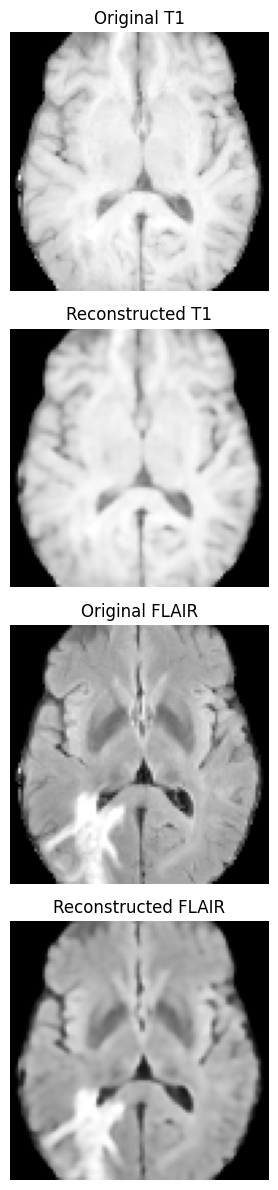

In [ ]:
visualize_reconstructions_for_batch(
    autoencoder=autoencoder,
    dataloader=test_loader,
    device=device,
    target_batch_idx=1,
    num_images=3
)

# Define diffusion model

After training the autoencoder on T2 volumes, the encoder is frozen and used to map both T1 and T2 images into a shared latent space. During diffusion training, Gaussian noise is added to the latent representation of the target T2 image at a randomly sampled timestep. The latent representation of the paired T1 image is concatenated with the noisy T2 latent and provided as conditional input to a 3D diffusion U-Net. The network is optimized to predict the injected noise using mean squared error loss, thereby learning to iteratively denoise the T2 latent under T1 guidance.

## ጐ Experiment Log: Diffusion Model Configurations

Keep track of your hyperparameter tuning iterations and their results here:

| Run | `beta_end` | `latent_l1_weight` | `img_l1_weight` | Mean SSIM | Mean PSNR | Notes / Observations |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **1** | 0.012 | 0.05 | 0.0 | ~0.3200 | ~12.7000 | Baseline with latent L1 loss. |
| **2** | 0.012 | 0.0 | 0.0 | ~0.3200 | ~12.7000 | Removing latent L1 didn't yield noticeable improvements. |
| **3** | 0.020 | 0.0 | 0.0 | 0.2100 | 10.4000 | Increasing noise schedule `beta_end` degraded performance. |
| **4** | 0.012 | 0.05 | 0.05 | 0.2682 | 14.3622 | Added image-space L1 loss (`img_l1_weight`). PSNR improved significantly, but SSIM dropped slightly compared to Run 1. |
| **5 (BEST)** | 0.012 | 0.05 | 0.05 | 0.3712 | 16.0399 | Continued training. Significant improvement across both SSIM and PSNR. FID achieved: 92.66. |
| **6** | 0.012 | 0.025 | 0.025 | 0.2649 | 13.8706 | Added 3D Perceptual Loss (weight=0.05) to improve realism and structural details. |
| **7** | 0.012 | 0.05 | 0.05 | 0.3460 | 15.8870 | Restored L1 weights to 0.05, reduced Perceptual Loss weight to 0.005 for subtle realism while retaining structure. |

In [ ]:
import os
import torch
import torch.nn.functional as F
from tqdm import tqdm
from torch.amp import autocast, GradScaler
from generative.networks.nets import DiffusionModelUNet
from generative.networks.schedulers import DDPMScheduler, DDIMScheduler

In [ ]:
# load trained autoencoder
ae_ckpt_path = "/content/drive/MyDrive/fyp_checkpoints/autoencoder_best_flair.pth"

checkpoint = torch.load(ae_ckpt_path, map_location=device)

# Case 1: full checkpoint dict
if "autoencoder_state_dict" in checkpoint:
    autoencoder.load_state_dict(checkpoint["autoencoder_state_dict"])
else:
    # Case 2: only weights saved
    autoencoder.load_state_dict(checkpoint)

print("Autoencoder weights loaded successfully.")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Freeze autoencoder
autoencoder.eval()
for p in autoencoder.parameters():
    p.requires_grad = False


Autoencoder weights loaded successfully.
Using device: cuda


In [ ]:
# define latent diffusion model
latent_channels = 8  # must match your trained autoencoder latent channels

unet = DiffusionModelUNet(
    spatial_dims=3,
    in_channels=latent_channels * 2,   # noisy z_t2 + z_t1
    out_channels=latent_channels,      # predict noise for z_t2
    num_res_blocks=3,
    num_channels=(64, 128, 256),
    attention_levels=(False, True, True),
    num_head_channels=(0, 64, 128),
).to(device)

scheduler = DDPMScheduler(
    num_train_timesteps=1000,
    schedule="scaled_linear_beta",
    beta_start=0.0015,
    beta_end=0.012,
)

optimizer_diff = torch.optim.AdamW(unet.parameters(), lr=7e-5, weight_decay=1e-5)

# optional LR scheduler
scheduler_lr = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_diff,
    mode="min",
    factor=0.5,
    patience=5
)

scaler = GradScaler(enabled=(device.type == "cuda"))

In [ ]:
import copy

ema_unet = copy.deepcopy(unet).to(device)
ema_unet.eval()

for p in ema_unet.parameters():
    p.requires_grad = False

In [ ]:
@torch.no_grad()
def update_ema(ema_model, model, decay=0.999):
    ema_params = dict(ema_model.named_parameters())
    model_params = dict(model.named_parameters())

    for name in ema_params:
        ema_params[name].mul_(decay).add_(model_params[name], alpha=1.0 - decay)

    # also keep buffers in sync if any
    ema_buffers = dict(ema_model.named_buffers())
    model_buffers = dict(model.named_buffers())

    for name in ema_buffers:
        ema_buffers[name].copy_(model_buffers[name])

In [ ]:
autoencoder.eval()
latents_std = []

with torch.no_grad():
    for i, batch in enumerate(train_loader):
        flair_sample = batch["flair"].to(device)

        z = autoencoder.encode_stage_2_inputs(flair_sample)
        latents_std.append(z.std().item())

        if i >= 9:
            break

scale_factor = 1.0 / np.mean(latents_std)

print(f"Scale factor: {scale_factor:.6f}")

Scale factor: 0.215154


In [ ]:
def min_snr_weight(timesteps, noise_scheduler, gamma=5.0):
    alphas_cumprod = noise_scheduler.alphas_cumprod.to(timesteps.device)
    alpha_t = alphas_cumprod[timesteps]

    snr = alpha_t / (1.0 - alpha_t)
    weights = torch.minimum(snr, torch.full_like(snr, gamma)) / snr

    return weights

def encode_latents(autoencoder, t1, flair, scale_factor):
    with torch.no_grad():
        z_t1 = autoencoder.encode_stage_2_inputs(t1) * scale_factor
        z_flair = autoencoder.encode_stage_2_inputs(flair) * scale_factor

    return z_t1, z_flair


def train_one_epoch(
    autoencoder,
    unet,
    ema_unet,
    noise_scheduler,
    train_loader,
    optimizer,
    scaler,
    device,
    scale_factor,
    grad_clip=1.0,
    min_snr_gamma=5.0,
    latent_l1_weight=0.05,
    img_l1_weight=0.05,
    perceptual_weight=0.0,
    perceptual_loss_fn=None,
    ema_decay=0.995,
    cfg_drop_prob=0.15,
):
    autoencoder.eval()
    unet.train()
    ema_unet.eval()

    running_loss = 0.0
    running_noise_loss = 0.0
    running_raw_mse = 0.0
    running_latent_l1 = 0.0
    running_img_l1 = 0.0
    running_p_loss = 0.0

    pbar = tqdm(train_loader, ncols=140, desc="Training")

    for step, batch in enumerate(pbar):
        t1 = batch["t1"].to(device, non_blocking=True)
        flair = batch["flair"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        z_t1, z_flair = encode_latents(
            autoencoder=autoencoder,
            t1=t1,
            flair=flair,
            scale_factor=scale_factor
        )

        # Classifier-Free Guidance: Randomly drop T1 conditioning
        if torch.rand(1).item() < cfg_drop_prob:
            z_t1 = torch.zeros_like(z_t1)

        noise = torch.randn_like(z_flair)

        timesteps = torch.randint(
            low=0,
            high=noise_scheduler.num_train_timesteps,
            size=(z_flair.shape[0],),
            device=device
        ).long()

        noisy_z_flair = noise_scheduler.add_noise(
            original_samples=z_flair,
            noise=noise,
            timesteps=timesteps
        )

        model_input = torch.cat([noisy_z_flair, z_t1], dim=1)

        with autocast(device_type="cuda", enabled=(device.type == "cuda")):
            noise_pred = unet(model_input, timesteps=timesteps)

            raw_mse = F.mse_loss(
                noise_pred.float(),
                noise.float()
            )

            mse_loss = F.mse_loss(
                noise_pred.float(),
                noise.float(),
                reduction="none"
            )

            mse_loss = mse_loss.flatten(1).mean(dim=1)

            weights = min_snr_weight(
                timesteps=timesteps,
                noise_scheduler=noise_scheduler,
                gamma=min_snr_gamma
            )

            noise_loss = (weights * mse_loss).mean()

            alphas_cumprod = noise_scheduler.alphas_cumprod.to(device)

            alpha_prod_t = alphas_cumprod[timesteps]
            alpha_prod_t = alpha_prod_t.view(
                -1,
                *([1] * (z_flair.ndim - 1))
            )

            pred_x0 = (
                noisy_z_flair.float()
                - torch.sqrt(1.0 - alpha_prod_t) * noise_pred.float()
            ) / torch.sqrt(alpha_prod_t)

            pred_x0 = torch.clamp(pred_x0, -5.0, 5.0)

            latent_l1 = F.l1_loss(
                pred_x0.float(),
                z_flair.float()
            )

            pred_flair = autoencoder.decode_stage_2_outputs(
                pred_x0 / scale_factor
            )

            img_l1 = F.l1_loss(
                pred_flair.float(),
                flair.float()
            )

            p_loss = torch.tensor(0.0, device=device)
            if perceptual_loss_fn is not None and perceptual_weight > 0:
                p_loss = perceptual_loss_fn(pred_flair.float(), flair.float())

            loss = (
                noise_loss
                + latent_l1_weight * latent_l1
                + img_l1_weight * img_l1
                + perceptual_weight * p_loss
            )

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            unet.parameters(),
            max_norm=grad_clip
        )

        scaler.step(optimizer)
        scaler.update()

        update_ema(
            ema_model=ema_unet,
            model=unet,
            decay=ema_decay
        )

        running_loss += loss.item()
        running_noise_loss += noise_loss.item()
        running_raw_mse += raw_mse.item()
        running_latent_l1 += latent_l1.item()
        running_img_l1 += img_l1.item()
        running_p_loss += p_loss.item()

        avg_loss = running_loss / (step + 1)
        avg_noise_loss = running_noise_loss / (step + 1)
        avg_raw_mse = running_raw_mse / (step + 1)
        avg_latent_l1 = running_latent_l1 / (step + 1)
        avg_img_l1 = running_img_l1 / (step + 1)
        avg_p_loss = running_p_loss / (step + 1)

        pbar.set_postfix(
            loss=f"{avg_loss:.4f}",
            noise=f"{avg_noise_loss:.4f}",
            raw=f"{avg_raw_mse:.4f}",
            l1_lat=f"{avg_latent_l1:.4f}",
            l1_img=f"{avg_img_l1:.4f}",
            p_loss=f"{avg_p_loss:.4f}",
            lr=f"{optimizer.param_groups[0]['lr']:.2e}"
        )

    return running_loss / len(train_loader)

@torch.no_grad()
def validate_one_epoch(
    autoencoder,
    eval_unet,
    noise_scheduler,
    val_loader,
    device,
    scale_factor,
    seed=42,
    min_snr_gamma=5.0,
    latent_l1_weight=0.05,
    img_l1_weight=0.05,
    perceptual_weight=0.0,
    perceptual_loss_fn=None,
):
    autoencoder.eval()
    eval_unet.eval()

    running_loss = 0.0
    running_noise_loss = 0.0
    running_raw_mse = 0.0
    running_latent_l1 = 0.0
    running_img_l1 = 0.0
    running_p_loss = 0.0

    g = torch.Generator(device=device)
    g.manual_seed(seed)

    pbar = tqdm(val_loader, ncols=140, desc="Validation")

    for step, batch in enumerate(pbar):
        t1 = batch["t1"].to(device, non_blocking=True)
        flair = batch["flair"].to(device, non_blocking=True)

        z_t1, z_flair = encode_latents(
            autoencoder=autoencoder,
            t1=t1,
            flair=flair,
            scale_factor=scale_factor
        )

        noise = torch.randn(
            z_flair.shape,
            generator=g,
            device=device,
            dtype=z_flair.dtype
        )

        timesteps = torch.randint(
            low=0,
            high=noise_scheduler.num_train_timesteps,
            size=(z_flair.shape[0],),
            generator=g,
            device=device
        ).long()

        noisy_z_flair = noise_scheduler.add_noise(
            original_samples=z_flair,
            noise=noise,
            timesteps=timesteps
        )

        model_input = torch.cat([noisy_z_flair, z_t1], dim=1)

        with autocast(device_type="cuda", enabled=(device.type == "cuda")):
            noise_pred = eval_unet(model_input, timesteps=timesteps)

            raw_mse = F.mse_loss(
                noise_pred.float(),
                noise.float()
            )

            mse_loss = F.mse_loss(
                noise_pred.float(),
                noise.float(),
                reduction="none"
            )

            mse_loss = mse_loss.flatten(1).mean(dim=1)

            weights = min_snr_weight(
                timesteps=timesteps,
                noise_scheduler=noise_scheduler,
                gamma=min_snr_gamma
            )

            noise_loss = (weights * mse_loss).mean()

            alphas_cumprod = noise_scheduler.alphas_cumprod.to(device)

            alpha_prod_t = alphas_cumprod[timesteps]
            alpha_prod_t = alpha_prod_t.view(
                -1,
                *([1] * (z_flair.ndim - 1))
            )

            pred_x0 = (
                noisy_z_flair.float()
                - torch.sqrt(1.0 - alpha_prod_t) * noise_pred.float()
            ) / torch.sqrt(alpha_prod_t)

            pred_x0 = torch.clamp(pred_x0, -5.0, 5.0)

            latent_l1 = F.l1_loss(
                pred_x0.float(),
                z_flair.float()
            )

            pred_flair = autoencoder.decode_stage_2_outputs(
                pred_x0 / scale_factor
            )

            img_l1 = F.l1_loss(
                pred_flair.float(),
                flair.float()
            )

            p_loss = torch.tensor(0.0, device=device)
            if perceptual_loss_fn is not None and perceptual_weight > 0:
                p_loss = perceptual_loss_fn(pred_flair.float(), flair.float())

            loss = (
                noise_loss
                + latent_l1_weight * latent_l1
                + img_l1_weight * img_l1
                + perceptual_weight * p_loss
            )

        running_loss += loss.item()
        running_noise_loss += noise_loss.item()
        running_raw_mse += raw_mse.item()
        running_latent_l1 += latent_l1.item()
        running_img_l1 += img_l1.item()
        running_p_loss += p_loss.item()

        avg_loss = running_loss / (step + 1)
        avg_noise_loss = running_noise_loss / (step + 1)
        avg_raw_mse = running_raw_mse / (step + 1)
        avg_latent_l1 = running_latent_l1 / (step + 1)
        avg_img_l1 = running_img_l1 / (step + 1)
        avg_p_loss = running_p_loss / (step + 1)

        pbar.set_postfix(
            val_loss=f"{avg_loss:.4f}",
            noise=f"{avg_noise_loss:.4f}",
            raw=f"{avg_raw_mse:.4f}",
            l1_lat=f"{avg_latent_l1:.4f}",
            l1_img=f"{avg_img_l1:.4f}",
            p_loss=f"{avg_p_loss:.4f}"
        )

    return running_loss / len(val_loader)

In [ ]:
import os
import torch
from generative.losses import PerceptualLoss

# ==== TRAINING CONFIG ====
resume_training = False
n_epochs = 500
early_stop_patience = 20
min_delta = 1e-5

save_dir = "/content/drive/MyDrive/fyp_checkpoints"
os.makedirs(save_dir, exist_ok=True)

latest_ckpt_path = os.path.join(save_dir, "latent_diffusion_latest_flair.pth")
best_ckpt_path = os.path.join(save_dir, "latent_diffusion_best_flair.pth")

# Initialize variables
start_epoch = 0
best_val_loss = float("inf")
no_improve_epochs = 0
train_loss_list = []
val_loss_list = []

# ==== RESUME LOGIC ====
if resume_training and os.path.exists(latest_ckpt_path):
    checkpoint = torch.load(
        latest_ckpt_path,
        map_location=device,
        weights_only=False
    )

    unet.load_state_dict(checkpoint["unet_state_dict"])
    ema_unet.load_state_dict(checkpoint["ema_unet_state_dict"])
    optimizer_diff.load_state_dict(checkpoint["optimizer_diff_state_dict"])

    if "scheduler_lr_state_dict" in checkpoint:
        scheduler_lr.load_state_dict(checkpoint["scheduler_lr_state_dict"])

    scaler.load_state_dict(checkpoint["scaler_state_dict"])

    start_epoch = checkpoint["epoch"]
    best_val_loss = checkpoint.get("best_val_loss", float("inf"))

    train_loss_list = checkpoint.get("train_loss_list", [])
    val_loss_list = checkpoint.get("val_loss_list", [])
    no_improve_epochs = checkpoint.get("no_improve_epochs", 0)

    print(f"Resumed T1 -> FLAIR diffusion from epoch {start_epoch}")
    print(f"Best val_loss: {best_val_loss:.6f}")

else:
    print("Starting T1 -> FLAIR diffusion training from scratch.")


# ==== PREPARE MODELS & LOSSES ====
autoencoder = autoencoder.to(device)
autoencoder.eval()

for p in autoencoder.parameters():
    p.requires_grad = False

loss_perceptual = PerceptualLoss(
    spatial_dims=3,
    network_type="squeeze",
    is_fake_3d=True,
    fake_3d_ratio=0.2,
).to(device)


# ==== TRAINING LOOP ====
for epoch in range(start_epoch, n_epochs):
    print(f"\nEpoch {epoch + 1}/{n_epochs}")

    train_loss = train_one_epoch(
        autoencoder=autoencoder,
        unet=unet,
        ema_unet=ema_unet,
        noise_scheduler=scheduler,
        train_loader=train_loader,
        optimizer=optimizer_diff,
        scaler=scaler,
        device=device,
        scale_factor=scale_factor,
        grad_clip=1.0,
        min_snr_gamma=5.0,
        latent_l1_weight=0.05,    # Run 7 configs
        img_l1_weight=0.05,       # Run 7 configs
        perceptual_weight=0.005,  # Run 7 configs
        perceptual_loss_fn=loss_perceptual,
        ema_decay=0.995,
    )

    val_loss = validate_one_epoch(
        autoencoder=autoencoder,
        eval_unet=ema_unet,
        noise_scheduler=scheduler,
        val_loader=val_loader,
        device=device,
        scale_factor=scale_factor,
        seed=1234,
        min_snr_gamma=5.0,
        latent_l1_weight=0.05,    # Run 7 configs
        img_l1_weight=0.05,       # Run 7 configs
        perceptual_weight=0.005,  # Run 7 configs
        perceptual_loss_fn=loss_perceptual,
    )

    scheduler_lr.step(val_loss)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    current_lr = optimizer_diff.param_groups[0]["lr"]

    print(
        f"Epoch {epoch + 1}: "
        f"train_loss={train_loss:.6f}, "
        f"val_loss={val_loss:.6f}, "
        f"lr={current_lr:.2e}"
    )

    checkpoint = {
        "epoch": epoch + 1,
        "unet_state_dict": unet.state_dict(),
        "ema_unet_state_dict": ema_unet.state_dict(),
        "optimizer_diff_state_dict": optimizer_diff.state_dict(),
        "scheduler_lr_state_dict": scheduler_lr.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "train_loss_list": train_loss_list,
        "val_loss_list": val_loss_list,
        "best_val_loss": best_val_loss,
        "scale_factor": scale_factor,
        "latent_channels": latent_channels,
        "no_improve_epochs": no_improve_epochs,
    }

    torch.save(checkpoint, latest_ckpt_path)

    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        no_improve_epochs = 0

        checkpoint["best_val_loss"] = best_val_loss
        checkpoint["no_improve_epochs"] = no_improve_epochs

        torch.save(checkpoint, best_ckpt_path)

        print(f"Best model saved at epoch {epoch + 1} with val_loss={val_loss:.6f}")

    else:
        no_improve_epochs += 1
        print(f"No improvement for {no_improve_epochs}/{early_stop_patience} epochs")

    if no_improve_epochs >= early_stop_patience:
        print(f"Early stopping triggered at epoch {epoch + 1}")
        print(f"Best val_loss: {best_val_loss:.6f}")
        break

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Starting T1 -> FLAIR diffusion training from scratch.

Epoch 1/500


Training: 100%|█| 99/99 [01:29<00:00,  1.11it/s, l1_img=0.4216, l1_lat=1.7241, loss=0.7976, lr=7.00e-05, noise=0.6836, p_loss=1.3385, raw=0.
Validation: 100%|███| 49/49 [00:14<00:00,  3.34it/s, l1_img=0.2941, l1_lat=0.9124, noise=0.1356, p_loss=1.0294, raw=0.1698, val_loss=0.2011]


Epoch 1: train_loss=0.797589, val_loss=0.201063, lr=7.00e-05
Best model saved at epoch 1 with val_loss=0.201063

Epoch 2/500


Training: 100%|█| 99/99 [01:29<00:00,  1.10it/s, l1_img=0.3597, l1_lat=1.4201, loss=0.3937, lr=7.00e-05, noise=0.2986, p_loss=1.2222, raw=0.
Validation: 100%|███| 49/49 [00:14<00:00,  3.38it/s, l1_img=0.3246, l1_lat=1.1080, noise=0.2133, p_loss=1.1043, raw=0.2553, val_loss=0.2905]


...

Training: 100%|█| 99/99 [01:28<00:00,  1.12it/s, l1_img=0.0888, l1_lat=0.1593, loss=0.0353, lr=7.00e-05, noise=0.0209, p_loss=0.4054, raw=0.
Validation: 100%|███| 49/49 [00:14<00:00,  3.29it/s, l1_img=0.0823, l1_lat=0.1341, noise=0.0177, p_loss=0.3463, raw=0.0366, val_loss=0.0303]


Epoch 246: train_loss=0.035305, val_loss=0.030257, lr=7.00e-05
Best model saved at epoch 246 with val_loss=0.030257

Epoch 247/500


Training: 100%|█| 99/99 [01:29<00:00,  1.11it/s, l1_img=0.0889, l1_lat=0.1527, loss=0.0333, lr=7.00e-05, noise=0.0192, p_loss=0.3977, raw=0.
Validation: 100%|███| 49/49 [00:14<00:00,  3.34it/s, l1_img=0.0825, l1_lat=0.1342, noise=0.0177, p_loss=0.3459, raw=0.0366, val_loss=0.0303]


Epoch 247: train_loss=0.033255, val_loss=0.030268, lr=7.00e-05
No improvement for 1/20 epochs

Epoch 248/500


Training:   3%| | 3/99 [00:08<03:28,  2.17s/it, l1_img=0.0964, l1_lat=0.1719, loss=0.0318, lr=7.00e-05, noise=0.0162, p_loss=0.4373, raw=0.0

Inference Code

In [ ]:
@torch.no_grad()
def generate_flair_from_t1(
    t1,
    autoencoder,
    unet,
    scheduler,
    scale_factor,
    device,
    num_inference_steps=50,
    guidance_scale=4.0,
):
    autoencoder.eval()
    for p in autoencoder.parameters():
      p.requires_grad = False
    unet.eval()

    t1 = t1.to(device)

    # Encode T1 to latent
    z_t1 = autoencoder.encode_stage_2_inputs(t1) * scale_factor
    # Create unconditional T1 (zeros)
    z_t1_uncond = torch.zeros_like(z_t1)

    # Start from pure noise for target T2 latent
    latent = torch.randn_like(z_t1, device=device)

    scheduler.set_timesteps(num_inference_steps=num_inference_steps)

    for t in scheduler.timesteps:
        if not torch.is_tensor(t):
            t = torch.tensor(t, device=device)

        timesteps = torch.full(
            (latent.shape[0],), t, device=device, dtype=torch.long
        )

        # --- CFG: Get Unconditional Prediction ---
        model_input_uncond = torch.cat([latent, z_t1_uncond], dim=1)
        noise_pred_uncond = unet(model_input_uncond, timesteps=timesteps)
        if hasattr(noise_pred_uncond, "sample"):
             noise_pred_uncond = noise_pred_uncond.sample

        # --- CFG: Get Conditional Prediction ---
        model_input_cond = torch.cat([latent, z_t1], dim=1)
        noise_pred_cond = unet(model_input_cond, timesteps=timesteps)
        if hasattr(noise_pred_cond, "sample"):
             noise_pred_cond = noise_pred_cond.sample

        # --- Apply Guidance ---
        noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_cond - noise_pred_uncond)

        step_output = scheduler.step(noise_pred, t, latent)
        latent = step_output[0] if isinstance(step_output, tuple) else step_output.prev_sample

    # Decode back to image space
    latent = latent / scale_factor
    pred_flair = autoencoder.decode_stage_2_outputs(latent)
    pred_flair = torch.clamp(pred_flair, -1.0, 1.0)

    return pred_flair


In [ ]:
import copy

ema_unet = copy.deepcopy(unet).to(device)
ema_unet.eval()

for p in ema_unet.parameters():
    p.requires_grad = False

In [ ]:
ae_ckpt_path = "/content/drive/MyDrive/fyp_checkpoints/autoencoder_best_flair.pth"
diff_ckpt_path = "/content/drive/MyDrive/fyp_checkpoints/latent_diffusion_best_flair.pth"

# Load autoencoder
print(f"Loading Autoencoder from: {ae_ckpt_path}")
ae_checkpoint = torch.load(ae_ckpt_path, map_location=device, weights_only=False)
if "autoencoder_state_dict" in ae_checkpoint:
    autoencoder.load_state_dict(ae_checkpoint["autoencoder_state_dict"])
else:
    autoencoder.load_state_dict(ae_checkpoint) # Case: only weights saved

autoencoder.to(device)
autoencoder.eval()
for p in autoencoder.parameters():
    p.requires_grad = False
print("Autoencoder loaded and frozen.")

# Load latent diffusion UNet
print(f"Loading Latent Diffusion UNet from: {diff_ckpt_path}")
diff_checkpoint = torch.load(diff_ckpt_path, map_location=device, weights_only=False)
# unet.load_state_dict(diff_checkpoint["unet_state_dict"])
ema_unet.load_state_dict(diff_checkpoint["ema_unet_state_dict"])

# unet.to(device)
# unet.eval()
ema_unet.to(device)
ema_unet.eval()

# Restore scale_factor, latent_channels from checkpoint if needed, otherwise use existing
if "scale_factor" in diff_checkpoint:
    scale_factor = diff_checkpoint["scale_factor"]
    print(f"Scale factor loaded from checkpoint: {scale_factor:.6f}")
if "latent_channels" in diff_checkpoint:
    latent_channels = diff_checkpoint["latent_channels"]
    print(f"Latent channels loaded from checkpoint: {latent_channels}")

print("Latent Diffusion UNet and EMA UNet loaded and set to eval mode.")

Tuning guidance scales. This will take a moment...


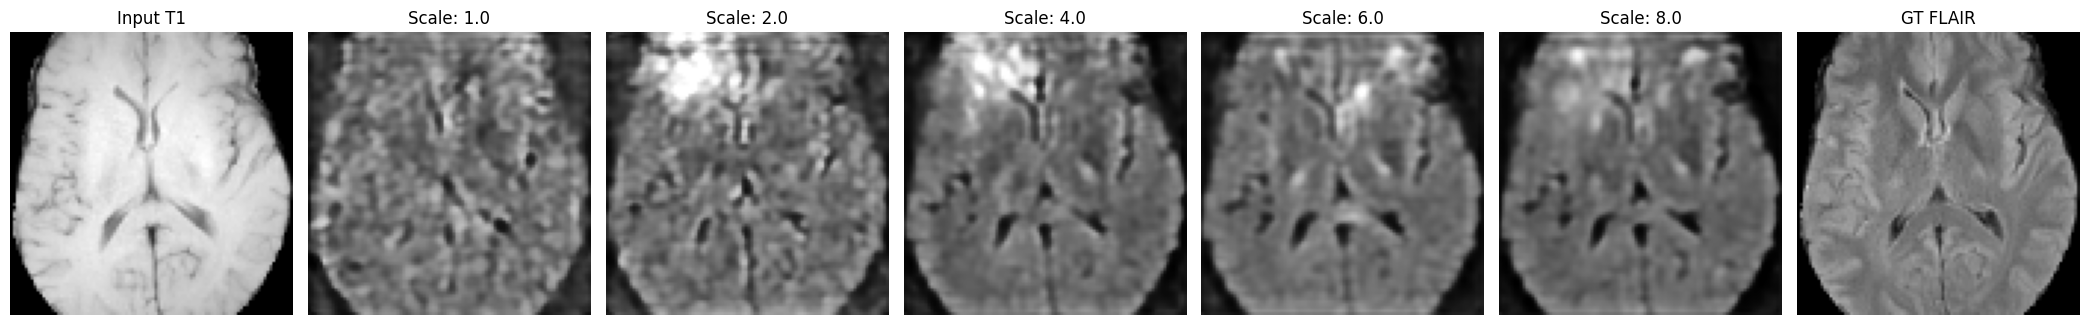

In [ ]:
import torch
from generative.networks.schedulers import DDIMScheduler
import matplotlib.pyplot as plt

def to_display_range(x):
    x = torch.clamp(x, -1.0, 1.0)
    return (x + 1.0) / 2.0

# Initialize DDIM for faster, deterministic inference (perfect for CFG)
ddim_scheduler = DDIMScheduler(
    num_train_timesteps=1000,
    schedule="scaled_linear_beta",
    beta_start=0.0015,
    beta_end=0.012,
    clip_sample=False
)

def tune_guidance_scale(t1_batch, gt_flair_batch, autoencoder, unet, scheduler, scale_factor, device, scales=[1.0, 2.0, 4.0, 6.0, 8.0]):
    print("Tuning guidance scales. This will take a moment...")

    plt.figure(figsize=(3 * (len(scales) + 2), 4))
    mid = t1_batch.shape[-1] // 2

    # Display helpers
    t1_disp = to_display_range(t1_batch)[0, 0].cpu().numpy()
    gt_disp = to_display_range(gt_flair_batch)[0, 0].cpu().numpy()

    # 1. Plot Input T1
    plt.subplot(1, len(scales) + 2, 1)
    plt.imshow(t1_disp[:, :, mid], cmap="gray", vmin=0, vmax=1)
    plt.title("Input T1")
    plt.axis("off")

    # 2. Iterate through guidance scales
    for i, scale in enumerate(scales):
        pred_flair = generate_flair_from_t1(
            t1=t1_batch,
            autoencoder=autoencoder,
            unet=unet,
            scheduler=scheduler,
            scale_factor=scale_factor,
            device=device,
            num_inference_steps=50,
            guidance_scale=scale
        )
        pred_disp = to_display_range(pred_flair)[0, 0].cpu().numpy()

        plt.subplot(1, len(scales) + 2, i + 2)
        plt.imshow(pred_disp[:, :, mid], cmap="gray", vmin=0, vmax=1)
        plt.title(f"Scale: {scale}")
        plt.axis("off")

    # 3. Plot Ground Truth FLAIR
    plt.subplot(1, len(scales) + 2, len(scales) + 2)
    plt.imshow(gt_disp[:, :, mid], cmap="gray", vmin=0, vmax=1)
    plt.title("GT FLAIR")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# Grab one batch from the test/val loader to test
for batch in val_loader:
    sample_t1 = batch["t1"].to(device)
    sample_flair = batch["flair"].to(device)
    break

# NOTE: Run this ONLY after you have trained the model with CFG (cfg_drop_prob > 0)
tune_guidance_scale(sample_t1, sample_flair, autoencoder, ema_unet, ddim_scheduler, scale_factor, device)


In [ ]:
# run inference on one batch
target_batch_idx = 1

for batch_idx, batch in enumerate(test_loader):
    if batch_idx == target_batch_idx:
        t1 = batch["t1"].to(device)
        flair = batch["flair"].to(device)
        break

print("Selected batch:", target_batch_idx)
print("T1 shape:", t1.shape)
print("GT flair shape:", flair.shape)

pred_flair = generate_flair_from_t1(
    t1=t1,
    autoencoder=autoencoder,
    unet=ema_unet,
    scheduler=ddim_scheduler,
    scale_factor=scale_factor,
    device=device,
    num_inference_steps=50,
    guidance_scale=4.0       # Update this based on the tuning results above!
)

print("T1 shape      :", t1.shape)
print("Pred flair shape :", pred_flair.shape)
print("GT flair shape   :", flair.shape)


Selected batch: 1
T1 shape: torch.Size([1, 1, 96, 96, 64])
GT flair shape: torch.Size([1, 1, 96, 96, 64])
T1 shape      : torch.Size([1, 1, 96, 96, 64])
Pred flair shape : torch.Size([1, 1, 96, 96, 64])
GT flair shape   : torch.Size([1, 1, 96, 96, 64])


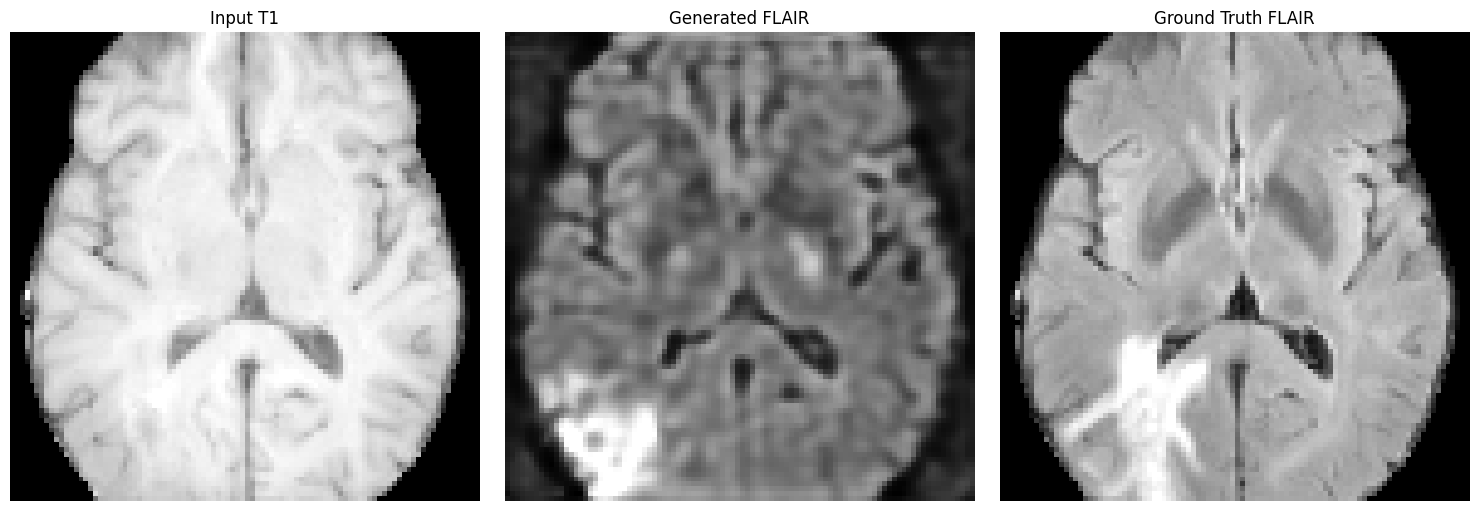

In [ ]:
# visualize a middle slice to see if the genration is reasonable
import matplotlib.pyplot as plt
def to_display_range(x):
    x = torch.clamp(x, -1.0, 1.0)
    return (x + 1.0) / 2.0


def show_middle_slice(t1, pred_flair, gt_flair, sample_idx=0):
    t1_disp = to_display_range(t1)
    pred_disp = to_display_range(pred_flair)
    gt_disp = to_display_range(gt_flair)

    t1_np = t1_disp[sample_idx, 0].detach().cpu().numpy()
    pred_np = pred_disp[sample_idx, 0].detach().cpu().numpy()
    gt_np = gt_disp[sample_idx, 0].detach().cpu().numpy()

    # Assuming volume shape is [H, W, D]
    mid = t1_np.shape[-1] // 2

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(t1_np[:, :, mid], cmap="gray", vmin=0, vmax=1)
    plt.title("Input T1")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(pred_np[:, :, mid], cmap="gray", vmin=0, vmax=1)
    plt.title("Generated FLAIR")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(gt_np[:, :, mid], cmap="gray", vmin=0, vmax=1)
    plt.title("Ground Truth FLAIR")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

show_middle_slice(t1, pred_flair, flair, sample_idx=0)

In [ ]:
!pip install torchmetrics
!pip install "torchmetrics[image]"
!pip install -q "torchmetrics[image]" torch-fidelity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 8.6 MB/s eta 0:00:00


test on the metrics

In [ ]:
import os
import numpy as np
import torch
import torch.nn.functional as F
from scipy import linalg
from torchvision.models import inception_v3, Inception_V3_Weights
from torchmetrics.image.kid import KernelInceptionDistance
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
class InceptionFeatureExtractor(torch.nn.Module):
    def __init__(self, device):
        super().__init__()

        weights = Inception_V3_Weights.DEFAULT
        model = inception_v3(weights=weights, transform_input=False)

        model.fc = torch.nn.Identity()
        model.eval()

        for p in model.parameters():
            p.requires_grad = False

        self.model = model.to(device)

    @torch.no_grad()
    def forward(self, x):
        """
        x shape: [B, 3, 299, 299]
        x range: [0, 1]
        """
        return self.model(x)

In [ ]:
#convert 3D mri to 2D centre slices
def volume_to_inception_slices(vol, max_slices=16):
    """
    vol shape: [D, H, W]
    vol range: [0, 1]
    return: [N, 3, 299, 299]
    """

    D = vol.shape[0]

    start = max(0, D // 2 - max_slices // 2)
    end = min(D, start + max_slices)

    imgs = []

    for z in range(start, end):
        img = vol[z]

        img = torch.tensor(img, dtype=torch.float32)
        img = img.unsqueeze(0).unsqueeze(0)

        img = F.interpolate(
            img,
            size=(299, 299),
            mode="bilinear",
            align_corners=False
        )

        img = img.repeat(1, 3, 1, 1)

        imgs.append(img)

    return torch.cat(imgs, dim=0)

In [ ]:
def compute_mu_sigma(features):
    features = np.asarray(features)

    mu = np.mean(features, axis=0)
    sigma = np.cov(features, rowvar=False)

    return mu, sigma


def calculate_fid(mu_real, sigma_real, mu_fake, sigma_fake, eps=1e-6):
    diff = mu_real - mu_fake

    covmean, _ = linalg.sqrtm(sigma_real @ sigma_fake, disp=False)

    if not np.isfinite(covmean).all():
        offset = np.eye(sigma_real.shape[0]) * eps
        covmean = linalg.sqrtm((sigma_real + offset) @ (sigma_fake + offset))

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = (
        diff @ diff
        + np.trace(sigma_real)
        + np.trace(sigma_fake)
        - 2 * np.trace(covmean)
    )

    return float(fid)

In [ ]:
feature_extractor = InceptionFeatureExtractor(device)

real_features = []

autoencoder.eval()
unet.eval()
ema_unet.eval()

with torch.no_grad():

    for batch_idx, batch in enumerate(test_loader):

        gt_flair = batch["flair"].to(device)
        gt_np = gt_flair.detach().cpu().numpy()

        B = gt_np.shape[0]

        for i in range(B):
            gt_vol = gt_np[i, 0]

            # Convert from [-1, 1] to [0, 1]
            gt_vol = np.clip(gt_vol, -1.0, 1.0)
            gt_vol = (gt_vol + 1.0) / 2.0

            imgs = volume_to_inception_slices(
                gt_vol,
                max_slices=16
            ).to(device)

            feats = feature_extractor(imgs)
            real_features.append(feats.detach().cpu().numpy())

real_features = np.concatenate(real_features, axis=0)

real_mu, real_sigma = compute_mu_sigma(real_features)

np.save("/content/real_flair_mu.npy", real_mu)
np.save("/content/real_flair_sigma.npy", real_sigma)

print("Saved real FLAIR stats")
print("Real feature shape:", real_features.shape)
print("Mu shape:", real_mu.shape)
print("Sigma shape:", real_sigma.shape)

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 235MB/s] 


Saved real FLAIR stats
Real feature shape: (800, 2048)
Mu shape: (2048,)
Sigma shape: (2048, 2048)


In [ ]:
!pip install -q "torchmetrics[image]" torch-fidelity

In [ ]:
real_mu = np.load("/content/real_flair_mu.npy")
real_sigma = np.load("/content/real_flair_sigma.npy")

psnr_list = []
ssim_list = []
fake_features = []
demo_results = []

kid = KernelInceptionDistance(
    subset_size=50,
    normalize=True
).to(device)

feature_extractor = InceptionFeatureExtractor(device)

autoencoder.eval()
ema_unet.eval()

for p in autoencoder.parameters():
    p.requires_grad = False


global_counter = 0

with torch.no_grad():

    for batch_idx, batch in enumerate(test_loader):

        t1 = batch["t1"].to(device)
        gt_flair = batch["flair"].to(device)

        pred_flair = generate_flair_from_t1(
            t1=t1,
            autoencoder=autoencoder,
            unet=ema_unet,
            scheduler=ddim_scheduler,
            scale_factor=scale_factor,
            device=device,
            num_inference_steps=1000
        )

        pred_np = pred_flair.detach().cpu().numpy()
        gt_np = gt_flair.detach().cpu().numpy()

        B = pred_np.shape[0]

        batch_psnr = []
        batch_ssim = []

        for i in range(B):

            global_idx = global_counter

            pred_vol = pred_np[i, 0]
            gt_vol = gt_np[i, 0]

            # Clip from training range [-1, 1]
            pred_vol = np.clip(pred_vol, -1.0, 1.0)
            gt_vol = np.clip(gt_vol, -1.0, 1.0)

            # Convert to [0, 1] for PSNR / SSIM / FID / KID
            pred_vol = (pred_vol + 1.0) / 2.0
            gt_vol = (gt_vol + 1.0) / 2.0

            # -----------------------------
            # PSNR
            # -----------------------------
            psnr_val = psnr(
                gt_vol,
                pred_vol,
                data_range=1.0
            )

            # -----------------------------
            # Slice-wise SSIM
            # Assuming volume shape is [H, W, D]
            # -----------------------------
            ssim_slices = []

            for z in range(pred_vol.shape[-1]):
                ssim_slice = ssim(
                    gt_vol[:, :, z],
                    pred_vol[:, :, z],
                    data_range=1.0
                )
                ssim_slices.append(ssim_slice)

            ssim_val = float(np.mean(ssim_slices))

            psnr_list.append(psnr_val)
            ssim_list.append(ssim_val)

            batch_psnr.append(psnr_val)
            batch_ssim.append(ssim_val)

            # -----------------------------
            # FID / KID features
            # -----------------------------
            real_imgs = volume_to_inception_slices(
                gt_vol,
                max_slices=16
            ).to(device)

            fake_imgs = volume_to_inception_slices(
                pred_vol,
                max_slices=16
            ).to(device)

            kid.update(real_imgs, real=True)
            kid.update(fake_imgs, real=False)

            feats = feature_extractor(fake_imgs)
            fake_features.append(feats.detach().cpu().numpy())

            sample_result = {
                "global_idx": global_idx,
                "batch_idx": batch_idx,
                "sample_idx_in_batch": i,
                "psnr": float(psnr_val),
                "ssim": float(ssim_val),
            }

            if "test_files" in globals() and global_idx < len(test_files):
                file_info = test_files[global_idx]
                sample_result["case_id"] = file_info["id"]
                sample_result["t1_file"] = file_info["t1"]
                sample_result["flair_file"] = file_info["flair"]

            demo_results.append(sample_result)

            global_counter += 1

        print(
            f"Batch {batch_idx:03d} | "
            f"PSNR: {np.mean(batch_psnr):.4f} | "
            f"SSIM: {np.mean(batch_ssim):.4f}"
        )


fake_features = np.concatenate(fake_features, axis=0)

fake_mu, fake_sigma = compute_mu_sigma(fake_features)

fid_value = calculate_fid(
    real_mu,
    real_sigma,
    fake_mu,
    fake_sigma
)

kid_mean, kid_std = kid.compute()

print("\n===== FINAL T1 -> FLAIR RESULTS =====")
print(f"Mean PSNR: {np.mean(psnr_list):.4f}")
print(f"Mean SSIM: {np.mean(ssim_list):.4f}")
print(f"FID: {fid_value:.4f}")
print(f"KID Mean: {kid_mean.item():.6f}")
print(f"KID Std: {kid_std.item():.6f}")

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Batch 000 | PSNR: 13.9414 | SSIM: 0.3714
Batch 001 | PSNR: 15.0889 | SSIM: 0.4088
Batch 002 | PSNR: 15.8589 | SSIM: 0.3700
Batch 003 | PSNR: 15.2965 | SSIM: 0.3186
Batch 004 | PSNR: 14.5932 | SSIM: 0.3344
Batch 005 | PSNR: 17.9052 | SSIM: 0.3828
Batch 006 | PSNR: 15.3682 | SSIM: 0.3600
Batch 007 | PSNR: 14.3754 | SSIM: 0.2791
Batch 008 | PSNR: 17.3483 | SSIM: 0.3754
Batch 009 | PSNR: 15.3141 | SSIM: 0.4365
Batch 010 | PSNR: 13.9259 | SSIM: 0.2702
Batch 011 | PSNR: 16.9130 | SSIM: 0.4152
Batch 012 | PSNR: 16.8713 | SSIM: 0.3665
Batch 013 | PSNR: 14.8027 | SSIM: 0.3817
Batch 014 | PSNR: 15.6815 | SSIM: 0.3560
Batch 015 | PSNR: 13.9685 | SSIM: 0.3707
Batch 016 | PSNR: 17.5053 | SSIM: 0.3733
Batch 017 | PSNR: 15.6802 | SSIM: 0.3620
Batch 018 | PSNR: 17.1142 | SSIM: 0.3353
Batch 019 | PSNR: 17.4147 | SSIM: 0.4373
Batch 020 | PSNR: 17.7414 | SSIM: 0.2831
Batch 021 | PSNR: 17.0034 | SSIM: 0.3861
Batch 022 | PSNR: 13.9048 | SSIM: 0.3614
Batch 023 | PSNR: 16.3564 | SSIM: 0.3862
Batch 024 | PSNR

/tmp/ipykernel_528/4138778820.py:13: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma_real @ sigma_fake, disp=False)



===== FINAL T1 -> FLAIR RESULTS =====
Mean PSNR: 16.0691
Mean SSIM: 0.3681
FID: 92.4822
KID Mean: 0.113278
KID Std: 0.011345


In [ ]:
demo_results_sorted = sorted(
    demo_results,
    key=lambda x: x["ssim"],
    reverse=True
)

best_sample = demo_results_sorted[0]
average_sample = demo_results_sorted[len(demo_results_sorted) // 2]
worst_sample = demo_results_sorted[-1]


def print_demo_sample(title, sample):
    print(f"\n===== {title} =====")
    print(f"Global Index: {sample['global_idx']}")
    print(f"Batch Index: {sample['batch_idx']}")
    print(f"Sample Index in Batch: {sample['sample_idx_in_batch']}")
    print(f"PSNR: {sample['psnr']:.4f}")
    print(f"SSIM: {sample['ssim']:.4f}")

    if "case_id" in sample:
        print(f"Case ID: {sample['case_id']}")
        print(f"T1 file: {sample['t1_file']}")

        if "flair_file" in sample:
            print(f"FLAIR file: {sample['flair_file']}")


print_demo_sample("BEST SAMPLE FOR DEMO", best_sample)
print_demo_sample("AVERAGE SAMPLE", average_sample)
print_demo_sample("WORST SAMPLE", worst_sample)


===== BEST SAMPLE FOR DEMO =====
Global Index: 34
Batch Index: 34
Sample Index in Batch: 0
PSNR: 17.9884
SSIM: 0.6947
Case ID: BraTS20_Training_303
T1 file: /content/dataset/final-clean-data/T1/BraTS20_Training_303_t1.nii
T2 file: /content/dataset/final-clean-data/T2/BraTS20_Training_303_t2.nii

===== AVERAGE SAMPLE =====
Global Index: 28
Batch Index: 28
Sample Index in Batch: 0
PSNR: 18.1237
SSIM: 0.6490
Case ID: BraTS20_Training_120
T1 file: /content/dataset/final-clean-data/T1/BraTS20_Training_120_t1.nii
T2 file: /content/dataset/final-clean-data/T2/BraTS20_Training_120_t2.nii

===== WORST SAMPLE =====
Global Index: 49
Batch Index: 49
Sample Index in Batch: 0
PSNR: 12.8085
SSIM: 0.4711
Case ID: BraTS20_Training_328
T1 file: /content/dataset/final-clean-data/T1/BraTS20_Training_328_t1.nii
T2 file: /content/dataset/final-clean-data/T2/BraTS20_Training_328_t2.nii


CUT OFF HERE

In [ ]:
import os
import numpy as np
import torch
import torch.nn.functional as F
from torchvision.models import inception_v3, Inception_V3_Weights

class InceptionFeatureExtractor(torch.nn.Module):
    def __init__(self, device):
        super().__init__()

        weights = Inception_V3_Weights.DEFAULT
        model = inception_v3(weights=weights, transform_input=False)
        model.fc = torch.nn.Identity()
        model.eval()

        for p in model.parameters():
            p.requires_grad = False

        self.model = model.to(device)

    @torch.no_grad()
    def forward(self, x):
        return self.model(x)

In [ ]:
def volume_to_inception_slices(vol, max_slices=16):
    """
    vol shape: [D, H, W] or [H, W, D]
    vol range expected: [-1, 1] or [0, 1]
    return: [N, 3, 299, 299]
    """

    vol = np.nan_to_num(vol.astype(np.float32))

    # If volume is [-1, 1], convert to [0, 1]
    if vol.min() < 0:
        vol = np.clip(vol, -1.0, 1.0)
        vol = (vol + 1.0) / 2.0
    else:
        vol = np.clip(vol, 0.0, 1.0)

    D = vol.shape[0]

    start = max(0, D // 2 - max_slices // 2)
    end = min(D, start + max_slices)

    imgs = []

    for z in range(start, end):
        img = vol[z]

        img = torch.tensor(img, dtype=torch.float32)
        img = img.unsqueeze(0).unsqueeze(0)

        img = F.interpolate(
            img,
            size=(299, 299),
            mode="bilinear",
            align_corners=False
        )

        img = img.repeat(1, 3, 1, 1)
        imgs.append(img)

    return torch.cat(imgs, dim=0)

In [ ]:
def compute_mu_sigma(features):
    features = np.asarray(features)

    mu = np.mean(features, axis=0)
    sigma = np.cov(features, rowvar=False)

    return mu, sigma

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

feature_extractor = InceptionFeatureExtractor(device)

real_t1_features = []

with torch.no_grad():

    for batch_idx, batch in enumerate(train_loader):

        t1 = batch["t1"].to(device)
        t1_np = t1.detach().cpu().numpy()

        B = t1_np.shape[0]

        for i in range(B):
            t1_vol = t1_np[i, 0]

            real_imgs = volume_to_inception_slices(
                t1_vol,
                max_slices=16
            ).to(device)

            feats = feature_extractor(real_imgs)

            real_t1_features.append(
                feats.detach().cpu().numpy()
            )

        print(f"Processed batch {batch_idx:03d}")

NameError: name 'torch' is not defined

In [ ]:
real_t1_features = np.concatenate(real_t1_features, axis=0)

real_t1_mu, real_t1_sigma = compute_mu_sigma(real_t1_features)

save_dir = "/content/drive/MyDrive/fyp_checkpoints/t1_synthesis_metrics"
os.makedirs(save_dir, exist_ok=True)

np.save(os.path.join(save_dir, "real_t1_mu.npy"), real_t1_mu)
np.save(os.path.join(save_dir, "real_t1_sigma.npy"), real_t1_sigma)

print("Saved real T1 reference stats")
print("Feature shape:", real_t1_features.shape)
print("Mu shape:", real_t1_mu.shape)
print("Sigma shape:", real_t1_sigma.shape)

Saved real T1 reference stats
Feature shape: (6320, 2048)
Mu shape: (2048,)
Sigma shape: (2048, 2048)


In [ ]:
import os
import numpy as np
import torch
import torch.nn.functional as F
from torchvision.models import inception_v3, Inception_V3_Weights
class InceptionFeatureExtractor(torch.nn.Module):
    def __init__(self, device):
        super().__init__()

        weights = Inception_V3_Weights.DEFAULT
        model = inception_v3(weights=weights, transform_input=False)
        model.fc = torch.nn.Identity()
        model.eval()

        for p in model.parameters():
            p.requires_grad = False

        self.model = model.to(device)

    @torch.no_grad()
    def forward(self, x):
        return self.model(x)

In [ ]:
def volume_to_inception_slices(vol, max_slices=16):
    """
    vol shape: [D, H, W] or [H, W, D]
    expected range: [-1, 1]
    output: [N, 3, 299, 299]
    """

    vol = np.nan_to_num(vol.astype(np.float32))

    vol = np.clip(vol, -1.0, 1.0)
    vol = (vol + 1.0) / 2.0

    D = vol.shape[0]

    start = max(0, D // 2 - max_slices // 2)
    end = min(D, start + max_slices)

    imgs = []

    for z in range(start, end):
        img = vol[z]  # if your volume is [D, H, W]

        img = torch.tensor(img, dtype=torch.float32)
        img = img.unsqueeze(0).unsqueeze(0)

        img = F.interpolate(
            img,
            size=(299, 299),
            mode="bilinear",
            align_corners=False
        )

        img = img.repeat(1, 3, 1, 1)
        imgs.append(img)

    return torch.cat(imgs, dim=0)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

feature_extractor = InceptionFeatureExtractor(device)

real_t1_features = []

with torch.no_grad():

    for batch_idx, batch in enumerate(train_loader):

        t1 = batch["t1"].to(device)
        t1_np = t1.detach().cpu().numpy()

        B = t1_np.shape[0]

        for i in range(B):
            t1_vol = t1_np[i, 0]

            real_imgs = volume_to_inception_slices(
                t1_vol,
                max_slices=16
            ).to(device)

            feats = feature_extractor(real_imgs)

            real_t1_features.append(
                feats.detach().cpu().numpy()
            )

        print(f"Processed batch {batch_idx:03d}")

Processed batch 000
Processed batch 001
Processed batch 002
Processed batch 003
Processed batch 004
Processed batch 005
Processed batch 006
Processed batch 007
Processed batch 008
Processed batch 009
Processed batch 010
Processed batch 011
Processed batch 012
Processed batch 013
Processed batch 014
Processed batch 015
Processed batch 016
Processed batch 017
Processed batch 018
Processed batch 019
Processed batch 020
Processed batch 021
Processed batch 022
Processed batch 023
Processed batch 024
Processed batch 025
Processed batch 026
Processed batch 027
Processed batch 028
Processed batch 029
Processed batch 030
Processed batch 031
Processed batch 032
Processed batch 033
Processed batch 034
Processed batch 035
Processed batch 036
Processed batch 037
Processed batch 038
Processed batch 039
Processed batch 040
Processed batch 041
Processed batch 042
Processed batch 043
Processed batch 044
Processed batch 045
Processed batch 046
Processed batch 047
Processed batch 048
Processed batch 049


In [ ]:
real_t1_features = np.concatenate(real_t1_features, axis=0)

save_dir = "/content/drive/MyDrive/fyp_checkpoints/t1_synthesis_metrics"
os.makedirs(save_dir, exist_ok=True)

np.save(
    os.path.join(save_dir, "real_t1_features.npy"),
    real_t1_features
)

print("Saved real T1 features")
print("Feature shape:", real_t1_features.shape)

Saved real T1 features
Feature shape: (6320, 2048)
